# 03. From forecast to strategy

A forecast is only useful if it changes what you do. Here each forecast sets the size
of a position: hold more SPY when tomorrow looks calm, less when it looks stormy, so
that the position always aims at 10 percent volatility a year. Then we backtest it
against simply buying and holding, after trading costs.

In [1]:
import sys
sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.strategy import volatility_target_weights
from src.backtest import run_backtest, buy_and_hold, compare_strategies, performance_metrics

ANN = np.sqrt(252)
MODELS = ["rolling", "ewma", "garch", "gjr", "egarch", "rf"]
fc = pd.read_csv("../data/processed/forecasts.csv", index_col=0, parse_dates=True)
r = fc["log_return"]

In [2]:
# Build one strategy per forecast, plus buy and hold as the benchmark.
results = {"buy_and_hold": buy_and_hold(r)}
for m in MODELS:
    w = volatility_target_weights(fc[m], target_vol=0.10, weight_cap=1.5)
    results[f"vt_{m}"] = run_backtest(w, r, cost_per_turn=0.0005)

compare_strategies(results).round(3)

,ann_return,ann_vol,sharpe,sortino,max_drawdown,calmar,pct_positive_days,avg_ann_turnover,avg_weight
buy_and_hold,0.114,0.199,0.642,0.782,-0.515,0.221,0.552,0.055,1.000
vt_rolling,0.082,0.110,0.770,0.983,-0.200,0.409,0.551,7.221,0.800
vt_ewma,0.077,0.105,0.763,0.983,-0.196,0.394,0.552,5.929,0.757
vt_garch,0.073,0.100,0.757,1.002,-0.211,0.347,0.551,12.128,0.730
vt_gjr,0.070,0.101,0.717,0.946,-0.218,0.319,0.551,13.038,0.755
vt_egarch,0.061,0.103,0.626,0.818,-0.268,0.227,0.551,15.623,0.762
vt_rf,0.086,0.117,0.758,1.013,-0.240,0.357,0.548,29.488,0.864


Two things stand out. First, volatility targeting works as risk control: every version
lands near 10 percent volatility and roughly halves the worst drawdown, from about -51
percent to around -20 percent, lifting the Sharpe from 0.64 to as much as 0.77.

Second, and more interesting, the best forecaster does not win the trade. Rolling and
EWMA give the best Sharpe. The GARCH models are more accurate but they react to every
twitch, so they trade about twice as much and give the edge back in costs. Accuracy and
profit are not the same thing.

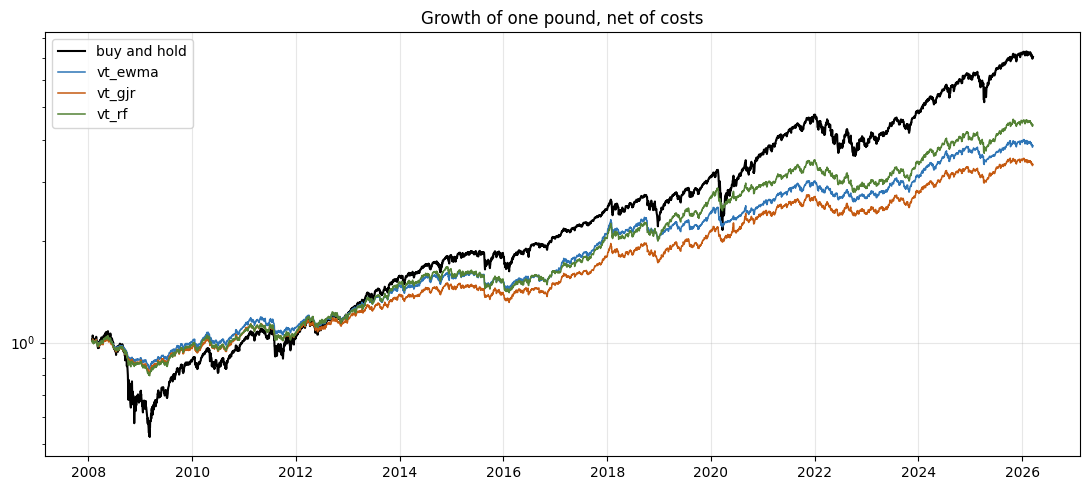

In [3]:
# Equity curves on a log scale, so equal percentage moves look equal.
equity = pd.DataFrame({name: bt["equity"] for name, bt in results.items()})
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(equity.index, equity["buy_and_hold"], color="black", lw=1.5, label="buy and hold")
for m, c in [("vt_ewma", "#2e75b6"), ("vt_gjr", "#c55a11"), ("vt_rf", "#548235")]:
    ax.plot(equity.index, equity[m], lw=1.1, label=m, color=c)
ax.set_yscale("log"); ax.set_title("Growth of one pound, net of costs"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Buy and hold finishes highest because it stayed fully exposed to a market that rose. The
strategy's value is not the finish line, it is the ride: look at 2008 to 2009, where buy
and hold halves and the targeted lines barely dip.

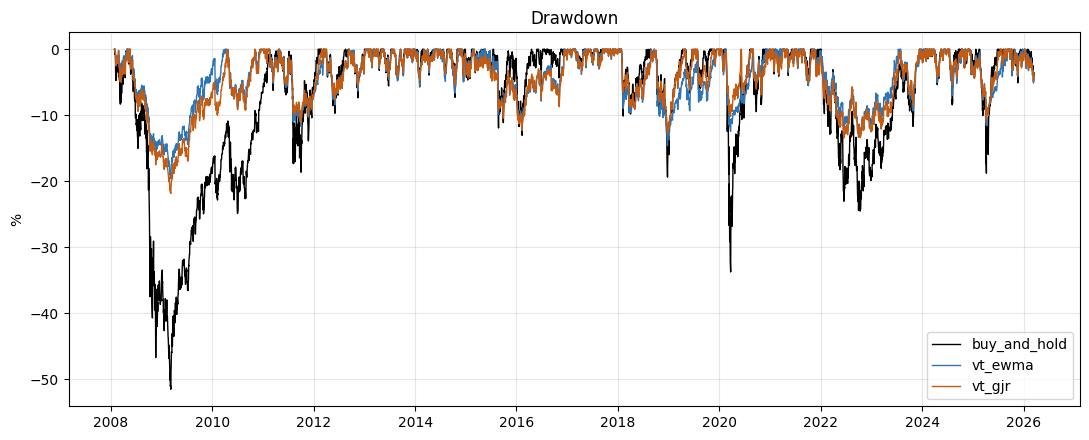

In [4]:
# Drawdown is the distance below the previous peak. Lower lines are safer.
fig, ax = plt.subplots(figsize=(11, 4.5))
for name, c in [("buy_and_hold", "black"), ("vt_ewma", "#2e75b6"), ("vt_gjr", "#c55a11")]:
    e = results[name]["equity"]
    ax.plot(e.index, (e / e.cummax() - 1) * 100, lw=1.0, label=name, color=c)
ax.set_title("Drawdown"); ax.set_ylabel("%"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Does the target level matter?

Raising the target just dials the exposure up. The realised volatility tracks whatever
you ask for and the Sharpe stays in a tight band, which is a sign the sizing rule is
behaving, not getting lucky at one setting.

In [5]:
rows = {}
for tv in [0.08, 0.10, 0.12, 0.15]:
    w = volatility_target_weights(fc["gjr"], target_vol=tv, weight_cap=1.5)
    bt = run_backtest(w, r, cost_per_turn=0.0005)
    m = performance_metrics(bt["net_ret"], name=f"target_{int(tv*100)}pct")
    m["realized_vol"] = bt["net_ret"].std() * ANN
    rows[f"target_{int(tv*100)}pct"] = m
pd.DataFrame(rows).T.round(3)

,ann_return,ann_vol,sharpe,sortino,max_drawdown,calmar,pct_positive_days,realized_vol
target_8pct,0.056,0.081,0.717,0.946,-0.178,0.315,0.551,0.081
target_10pct,0.070,0.101,0.717,0.946,-0.218,0.319,0.551,0.101
target_12pct,0.083,0.121,0.721,0.952,-0.257,0.323,0.551,0.121
target_15pct,0.103,0.147,0.738,0.975,-0.311,0.330,0.551,0.147


## How it holds up in each crisis

The point of the strategy is to lose less when it counts. Total return, volatility and
worst drawdown, for buy and hold and two of the strategies, across the three big shocks.

In [6]:
crises = {"GFC_2008": ("2008-09-01", "2009-06-30"),
          "COVID_2020": ("2020-02-15", "2020-06-30"),
          "Bear_2022": ("2022-01-01", "2022-12-31")}
rows = {}
for cname, (a, b) in crises.items():
    for sname in ["buy_and_hold", "vt_ewma", "vt_gjr"]:
        bt = results[sname].loc[a:b]
        e = (1 + bt["net_ret"]).cumprod()
        rows[f"{cname} | {sname}"] = {"total_return": (1 + bt["net_ret"]).prod() - 1,
                                      "ann_vol": bt["net_ret"].std() * ANN,
                                      "max_dd": (e / e.cummax() - 1).min()}
pd.DataFrame(rows).T.round(3)

,total_return,ann_vol,max_dd
GFC_2008 | buy_and_hold,-0.267,0.493,-0.460
GFC_2008 | vt_ewma,-0.071,0.106,-0.141
GFC_2008 | vt_gjr,-0.088,0.112,-0.156
COVID_2020 | buy_and_hold,-0.077,0.510,-0.337
COVID_2020 | vt_ewma,-0.072,0.124,-0.124
COVID_2020 | vt_gjr,-0.030,0.148,-0.099
Bear_2022 | buy_and_hold,-0.182,0.242,-0.245
Bear_2022 | vt_ewma,-0.103,0.105,-0.132
Bear_2022 | vt_gjr,-0.103,0.112,-0.124
